# Agentic RAG Benchmark: Publication Plots 
This notebook parses the statistical evaluations and generates the publication-ready charts (Cost vs Performance, Latency, and Reasoning Degradation).


In [4]:
%pip install seaborn pandas matplotlib numpy

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set publication stylings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('paper', font_scale=1.5)

# Load the full dataset (focusing on the large 7405 question sweep)
df = pd.read_csv('../full_stats_table.csv')
df = df[df['num_questions'] > 5000].copy()  # Filter out small test runs

# Calculate error margins for plots
df['f1_err_lower'] = df['f1'] - df['f1_ci_lower']
df['f1_err_upper'] = df['f1_ci_upper'] - df['f1']


## 1. The Pareto Frontier: Cost vs. F1 Score
This plot maps how expensive each architecture is compared to its reasoning performance. It highlights that Vanilla RAG and Recursive RLM are highly efficient, while ReAct is wildly expensive for minimal F1 gains.

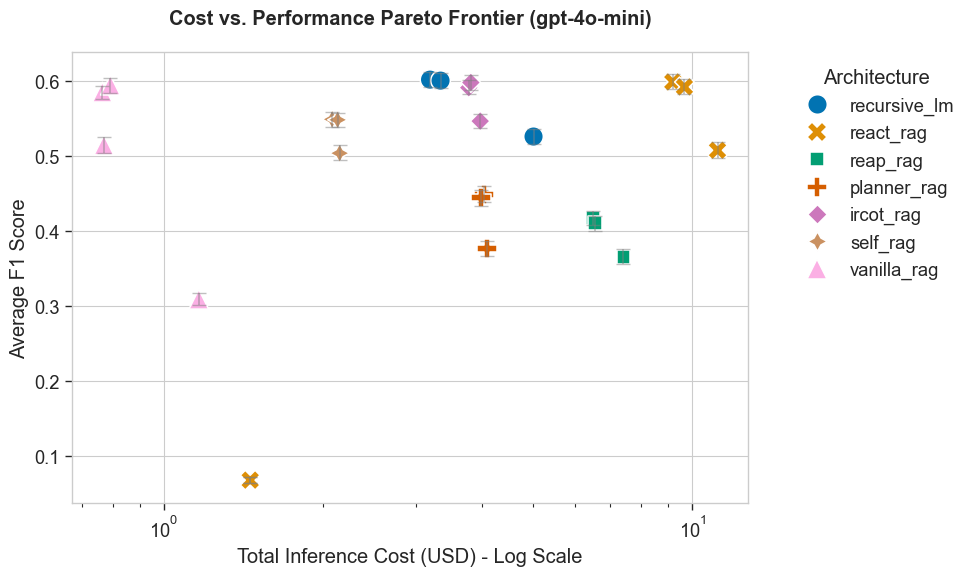

In [9]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='cost_usd', 
    y='f1', 
    hue='architecture', 
    style='architecture',
    s=200, 
    palette='colorblind'
)

# Add error bars for statistical confidence
for _, row in df.iterrows():
    plt.errorbar(
        row['cost_usd'], row['f1'], 
        yerr=[[row['f1_err_lower']], [row['f1_err_upper']]], 
        fmt='none', capsize=5, color='gray', alpha=0.5
    )

plt.xscale('log')
plt.title('Cost vs. Performance Pareto Frontier (gpt-4o-mini)', pad=20, weight='bold')
plt.xlabel('Total Inference Cost (USD) - Log Scale')
plt.ylabel('Average F1 Score')
plt.legend(title='Architecture', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('results/cost_vs_f1_pareto.png', dpi=300, bbox_inches='tight')
plt.show()


## 2. Latency Penalty Analysis
Agentic architectures require iterative execution. This plot shows the time-to-answer tradeoff.

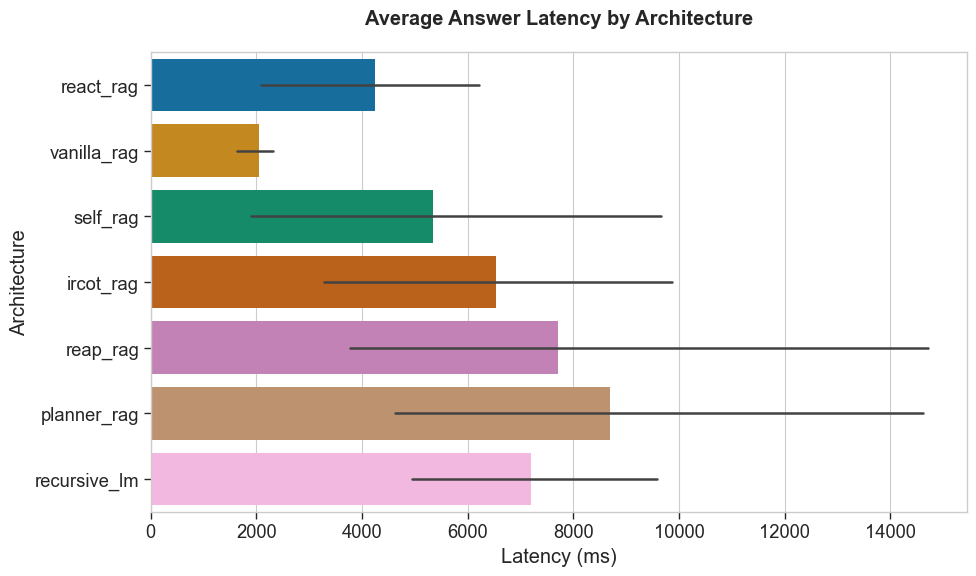

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df.sort_values('latency_ms'), 
    x='latency_ms', 
    y='architecture', 
    hue='architecture', 
    dodge=False, 
    palette='colorblind'
)

plt.title('Average Answer Latency by Architecture', pad=20, weight='bold')
plt.xlabel('Latency (ms)')
plt.ylabel('Architecture')
plt.tight_layout()
plt.savefig('results/latency_comparison.png', dpi=300)
plt.show()


## 3. Token Efficiency (Context explosion)
Bar chart showing how structured planning (Planner RAG) and iterative acting (ReAct) consume vast numbers of tokens.

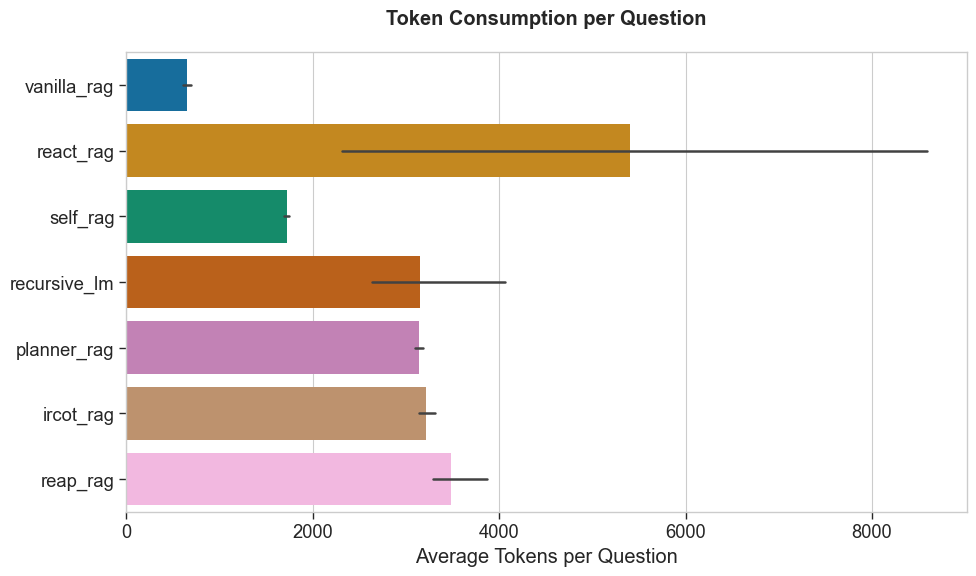

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df.sort_values('tokens_per_q'), 
    x='tokens_per_q', 
    y='architecture', 
    hue='architecture', 
    dodge=False, 
    palette='colorblind'
)

plt.title('Token Consumption per Question', pad=20, weight='bold')
plt.xlabel('Average Tokens per Question')
plt.ylabel('')
plt.tight_layout()
plt.savefig('results/token_usage.png', dpi=300)
plt.show()
